# KNN for regression

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import cross_val_score

# 设置随机种子
np.random.seed(42)

# 读取回归数据集 - 这是一个两列的数据集（x, y）
data = pd.read_csv("../datasets/w3regr.csv", header=None, names=["x", "y"])
print("数据集加载完成")

# 数据探索和分析
print("数据集形状:", data.shape)
print("\n数据集前10行:")
print(data.head(10))
print("\n数据集基本信息:")
print(data.info())
print("\n数据集统计信息:")
print(data.describe())
print("\n检查缺失值:")
print(data.isnull().sum())

数据集加载完成
数据集形状: (81, 2)

数据集前10行:
     x           y
0 -5.0  123.867799
1 -4.9   63.138296
2 -4.8    4.163196
3 -4.7   -0.163918
4 -4.6  -33.727488
5 -4.5  -38.119515
6 -4.4  -65.966381
7 -4.3  -92.429615
8 -4.2  -91.684628
9 -4.1  -97.780406

数据集基本信息:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 81 entries, 0 to 80
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x       81 non-null     float64
 1   y       81 non-null     float64
dtypes: float64(2)
memory usage: 1.4 KB
None

数据集统计信息:
               x           y
count  81.000000   81.000000
mean   -1.000000  -31.954204
std     2.352658   45.178432
min    -5.000000 -136.873070
25%    -3.000000  -67.873059
50%    -1.000000  -20.579055
75%     1.000000   -2.436370
max     3.000000  123.867799

检查缺失值:
x    0
y    0
dtype: int64


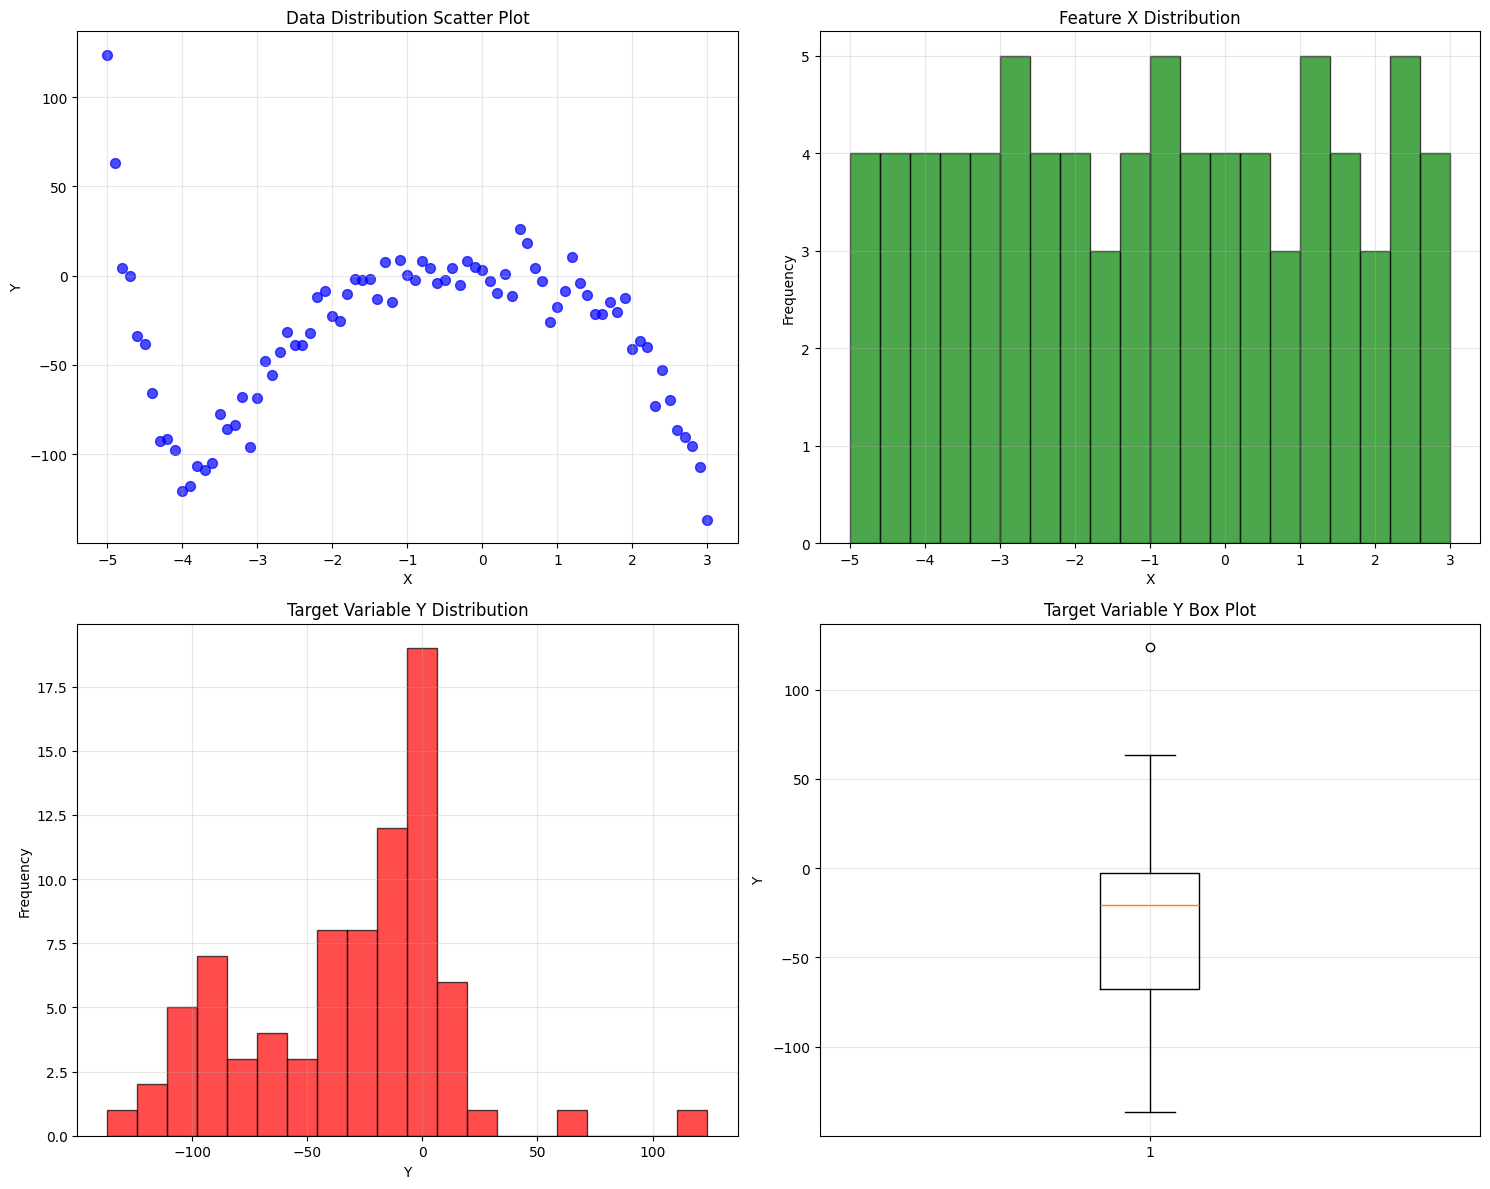


Correlation between X and Y: 0.0613


In [3]:
# 数据可视化
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 散点图显示数据分布
axes[0, 0].scatter(data["x"], data["y"], alpha=0.7, color="blue", s=50)
axes[0, 0].set_xlabel("X")
axes[0, 0].set_ylabel("Y")
axes[0, 0].set_title("Data Distribution Scatter Plot")
axes[0, 0].grid(True, alpha=0.3)

# X的分布直方图
axes[0, 1].hist(data["x"], bins=20, alpha=0.7, color="green", edgecolor="black")
axes[0, 1].set_xlabel("X")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].set_title("Feature X Distribution")
axes[0, 1].grid(True, alpha=0.3)

# Y的分布直方图
axes[1, 0].hist(data["y"], bins=20, alpha=0.7, color="red", edgecolor="black")
axes[1, 0].set_xlabel("Y")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].set_title("Target Variable Y Distribution")
axes[1, 0].grid(True, alpha=0.3)

# 箱线图显示Y的分布
axes[1, 1].boxplot(data["y"])
axes[1, 1].set_ylabel("Y")
axes[1, 1].set_title("Target Variable Y Box Plot")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 计算相关系数
correlation = data["x"].corr(data["y"])
print(f"\nCorrelation between X and Y: {correlation:.4f}")

In [ ]:
# 数据预处理
# 将数据重塑为适当的形状
X = data["x"].values.reshape(-1, 1)  # 回归需要2D数组
y = data["y"].values

print("特征矩阵 X 的形状:", X.shape)
print("标签向量 y 的形状:", y.shape)
print("特征矩阵 X 的前5行:")
print(X[:5])
print("标签向量 y 的前5个值:")
print(y[:5])

# 数据分割：训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"\n训练集大小: {X_train.shape[0]}")
print(f"测试集大小: {X_test.shape[0]}")

# 特征标准化（对于KNN回归也很重要）
scaler_X = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# 对于回归，目标变量通常不需要标准化，但我们保持原始y值
y_train_scaled = y_train
y_test_scaled = y_test

print("\n标准化前训练集特征统计:")
print("均值:", np.mean(X_train, axis=0))
print("标准差:", np.std(X_train, axis=0))

print("\n标准化后训练集特征统计:")
print("均值:", np.mean(X_train_scaled, axis=0))
print("标准差:", np.std(X_train_scaled, axis=0))

特征矩阵 X 的形状: (81, 1)
标签向量 y 的形状: (81,)
特征矩阵 X 的前5行:
[[-5. ]
 [-4.9]
 [-4.8]
 [-4.7]
 [-4.6]]
标签向量 y 的前5个值:
[123.8677989   63.13829606   4.16319567  -0.16391839 -33.72748781]

训练集大小: 64
测试集大小: 17

标准化前训练集特征统计:
均值: [-0.8671875]
标准差: [2.33091014]

标准化后训练集特征统计:
均值: [-2.77555756e-17]
标准差: [1.]


In [5]:
# KNN回归算法从零实现
class KNNRegressor:
    def __init__(self, k=3):
        """
        初始化KNN回归器

        参数:
        k: 邻居数量
        """
        self.k = k

    def fit(self, X_train, y_train):
        """
        训练KNN回归模型（实际上只是存储训练数据）

        参数:
        X_train: 训练特征
        y_train: 训练标签
        """
        self.X_train = X_train
        self.y_train = y_train
        print(f"KNN回归模型已训练，k={self.k}")
        print(f"训练数据包含 {len(X_train)} 个样本")

    def euclidean_distance(self, point1, point2):
        """
        计算两点间的欧几里得距离

        参数:
        point1, point2: 两个数据点

        返回:
        欧几里得距离
        """
        return np.sqrt(np.sum((point1 - point2) ** 2))

    def predict_single(self, x):
        """
        预测单个样本

        参数:
        x: 单个测试样本

        返回:
        预测的连续值（k个邻居的平均值）
        """
        # 计算测试点到所有训练点的距离
        distances = []
        for i in range(len(self.X_train)):
            dist = self.euclidean_distance(x, self.X_train[i])
            distances.append((dist, self.y_train[i]))

        # 按距离排序，选择k个最近的邻居
        distances.sort(key=lambda x: x[0])
        k_nearest = distances[: self.k]

        # 获取k个邻居的目标值
        k_nearest_values = [value for _, value in k_nearest]

        # 计算平均值作为预测结果
        prediction = np.mean(k_nearest_values)
        return prediction

    def predict(self, X_test):
        """
        预测多个样本

        参数:
        X_test: 测试特征

        返回:
        预测值列表
        """
        predictions = []
        for i, x in enumerate(X_test):
            if i % 10 == 0:  # 每10个样本显示一次进度
                print(f"正在预测第 {i+1}/{len(X_test)} 个样本...")
            pred = self.predict_single(x)
            predictions.append(pred)
        return np.array(predictions)


# 创建KNN回归器实例
knn_custom = KNNRegressor(k=5)
knn_custom.fit(X_train_scaled, y_train_scaled)

KNN回归模型已训练，k=5
训练数据包含 64 个样本


开始预测...
正在预测第 1/17 个样本...
正在预测第 11/17 个样本...

自定义KNN回归性能:
均方误差 (MSE): 1101.9759
均方根误差 (RMSE): 33.1960
平均绝对误差 (MAE): 15.3506
决定系数 (R²): 0.5935


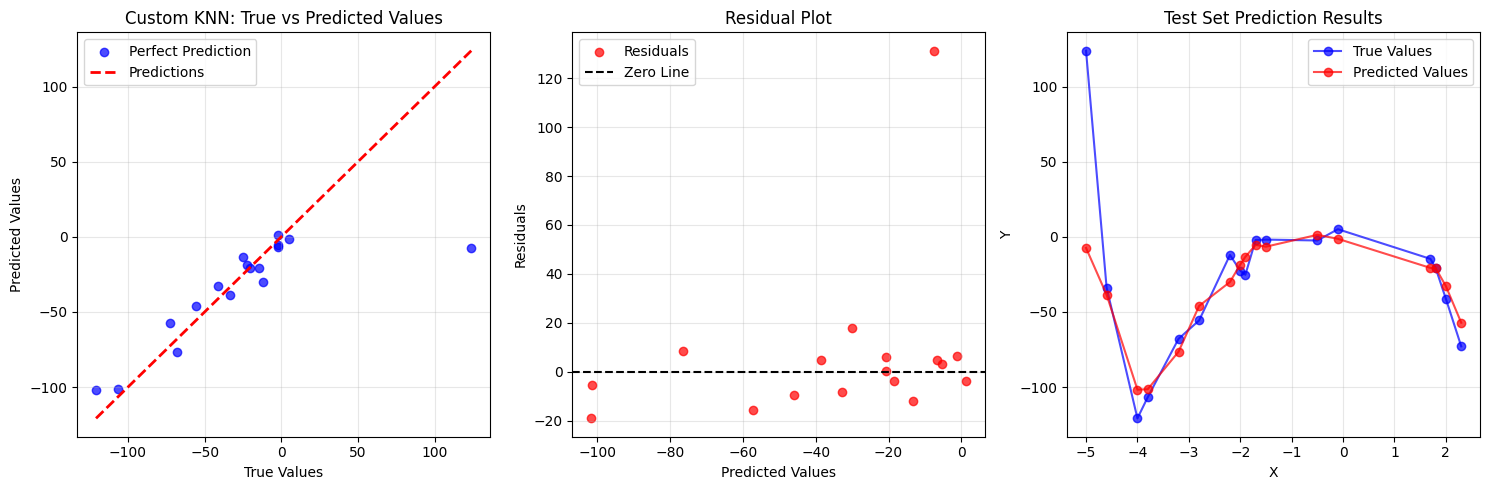

In [15]:
# 使用自定义KNN进行预测
print("开始预测...")
y_pred_custom = knn_custom.predict(X_test_scaled)

# 计算回归评估指标
mse_custom = mean_squared_error(y_test_scaled, y_pred_custom)
rmse_custom = np.sqrt(mse_custom)
mae_custom = mean_absolute_error(y_test_scaled, y_pred_custom)
r2_custom = r2_score(y_test_scaled, y_pred_custom)

print(f"\n自定义KNN回归性能:")
print(f"均方误差 (MSE): {mse_custom:.4f}")
print(f"均方根误差 (RMSE): {rmse_custom:.4f}")
print(f"平均绝对误差 (MAE): {mae_custom:.4f}")
print(f"决定系数 (R²): {r2_custom:.4f}")

# 可视化预测结果
plt.figure(figsize=(15, 5))

# 真实值 vs 预测值散点图
plt.subplot(1, 3, 1)
plt.scatter(y_test_scaled, y_pred_custom, alpha=0.7, color="blue")
plt.plot(
    [y_test_scaled.min(), y_test_scaled.max()],
    [y_test_scaled.min(), y_test_scaled.max()],
    "r--",
    lw=2,
)
plt.xlabel("True Values")
plt.ylabel("Predicted Values")
plt.title("Custom KNN: True vs Predicted Values")
plt.legend(["Perfect Prediction", "Predictions"])
plt.grid(True, alpha=0.3)

# 残差图
plt.subplot(1, 3, 2)
residuals = y_test_scaled - y_pred_custom
plt.scatter(y_pred_custom, residuals, alpha=0.7, color="red")
plt.axhline(y=0, color="black", linestyle="--")
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.legend(["Residuals", "Zero Line"])
plt.grid(True, alpha=0.3)

# 预测结果在原始数据上的显示
plt.subplot(1, 3, 3)
# 获取测试集的原始X值用于排序显示
test_indices = np.argsort(X_test.flatten())
plt.plot(
    X_test[test_indices].flatten(),
    y_test_scaled[test_indices],
    "bo-",
    label="True Values",
    alpha=0.7,
    markersize=6,
)
plt.plot(
    X_test[test_indices].flatten(),
    y_pred_custom[test_indices],
    "ro-",
    label="Predicted Values",
    alpha=0.7,
    markersize=6,
)
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Test Set Prediction Results")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# 使用scikit-learn的KNN回归进行对比
# 创建sklearn的KNN回归器
knn_sklearn = KNeighborsRegressor(n_neighbors=5)

# 训练模型
knn_sklearn.fit(X_train_scaled, y_train_scaled)

# 预测
y_pred_sklearn = knn_sklearn.predict(X_test_scaled)

# 计算评估指标
mse_sklearn = mean_squared_error(y_test_scaled, y_pred_sklearn)
rmse_sklearn = np.sqrt(mse_sklearn)
mae_sklearn = mean_absolute_error(y_test_scaled, y_pred_sklearn)
r2_sklearn = r2_score(y_test_scaled, y_pred_sklearn)

print(f"Scikit-learn KNN回归性能:")
print(f"均方误差 (MSE): {mse_sklearn:.4f}")
print(f"均方根误差 (RMSE): {rmse_sklearn:.4f}")
print(f"平均绝对误差 (MAE): {mae_sklearn:.4f}")
print(f"决定系数 (R²): {r2_sklearn:.4f}")

# 比较两种实现的结果
print(f"\n结果对比:")
print(f"自定义KNN - RMSE: {rmse_custom:.4f}, R²: {r2_custom:.4f}")
print(f"Scikit-learn KNN - RMSE: {rmse_sklearn:.4f}, R²: {r2_sklearn:.4f}")

# 预测结果的差异
pred_diff = np.abs(y_pred_custom - y_pred_sklearn)
print(f"预测结果的平均绝对差异: {np.mean(pred_diff):.6f}")
print(f"预测结果的最大差异: {np.max(pred_diff):.6f}")

if np.allclose(y_pred_custom, y_pred_sklearn, atol=1e-10):
    print("两种实现的预测结果基本一致")
else:
    print("两种实现的预测结果存在细微差异（这是正常的）")

Scikit-learn KNN回归性能:
均方误差 (MSE): 1101.9759
均方根误差 (RMSE): 33.1960
平均绝对误差 (MAE): 15.3506
决定系数 (R²): 0.5935

结果对比:
自定义KNN - RMSE: 33.1960, R²: 0.5935
Scikit-learn KNN - RMSE: 33.1960, R²: 0.5935
预测结果的平均绝对差异: 0.000000
预测结果的最大差异: 0.000000
两种实现的预测结果基本一致


正在测试不同的k值...
k=1: 交叉验证RMSE = 18.0318 (±5.1714)
k=2: 交叉验证RMSE = 16.7765 (±6.2678)
k=3: 交叉验证RMSE = 19.0352 (±7.4957)
k=4: 交叉验证RMSE = 20.6954 (±9.9110)
k=5: 交叉验证RMSE = 22.9354 (±10.5864)
k=6: 交叉验证RMSE = 25.2245 (±11.2054)
k=7: 交叉验证RMSE = 27.4055 (±12.4016)
k=8: 交叉验证RMSE = 28.4761 (±13.0516)
k=9: 交叉验证RMSE = 29.4295 (±12.0897)
k=10: 交叉验证RMSE = 30.2545 (±12.1411)
k=11: 交叉验证RMSE = 31.0663 (±11.9014)
k=12: 交叉验证RMSE = 32.1292 (±12.2107)
k=13: 交叉验证RMSE = 32.3986 (±11.7329)
k=14: 交叉验证RMSE = 32.7647 (±11.5750)
k=15: 交叉验证RMSE = 33.0845 (±11.1916)
k=16: 交叉验证RMSE = 33.7053 (±10.7925)
k=17: 交叉验证RMSE = 34.1777 (±10.3671)
k=18: 交叉验证RMSE = 34.9579 (±10.1326)
k=19: 交叉验证RMSE = 35.3117 (±9.7413)
k=20: 交叉验证RMSE = 35.9455 (±9.3170)

最佳k值: 2, 最佳交叉验证RMSE: 16.7765
k=20: 交叉验证RMSE = 35.9455 (±9.3170)

最佳k值: 2, 最佳交叉验证RMSE: 16.7765


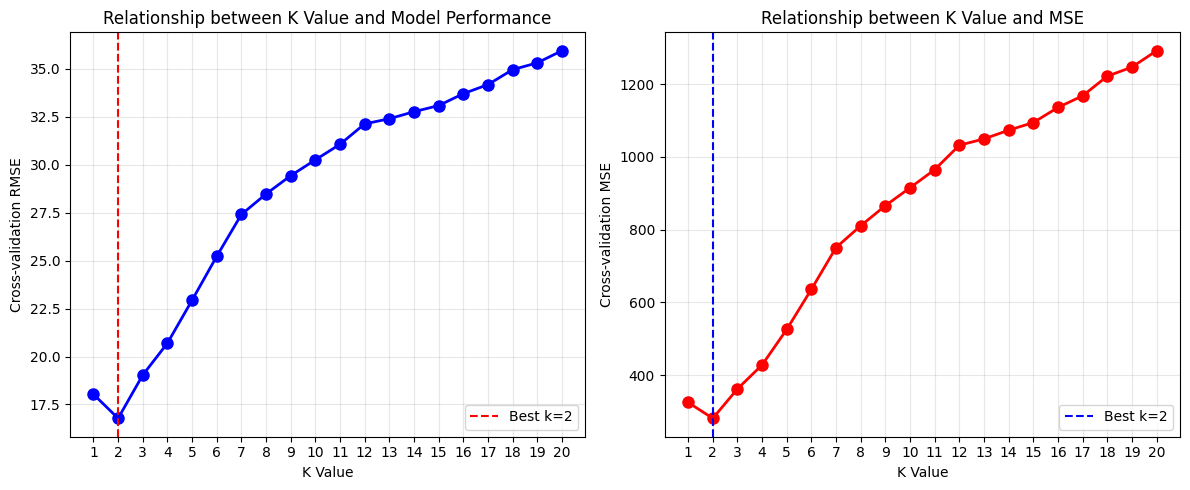

In [8]:
# K值优化 - 寻找最佳k值
# 测试不同的k值
k_values = range(1, 21)
cv_scores = []
mse_scores = []

print("正在测试不同的k值...")
for k in k_values:
    knn = KNeighborsRegressor(n_neighbors=k)
    # 使用5折交叉验证，评估指标使用负均方误差（越大越好）
    scores = cross_val_score(
        knn, X_train_scaled, y_train_scaled, cv=5, scoring="neg_mean_squared_error"
    )
    # 转换为正的MSE
    mse_cv = -scores.mean()
    rmse_cv = np.sqrt(mse_cv)

    cv_scores.append(rmse_cv)
    mse_scores.append(mse_cv)

    print(f"k={k}: 交叉验证RMSE = {rmse_cv:.4f} (±{np.sqrt(-scores).std():.4f})")

# 找到最佳k值（最小RMSE）
best_k = k_values[np.argmin(cv_scores)]
best_rmse = min(cv_scores)
print(f"\n最佳k值: {best_k}, 最佳交叉验证RMSE: {best_rmse:.4f}")

# 可视化k值与RMSE的关系
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(k_values, cv_scores, "bo-", linewidth=2, markersize=8)
plt.axvline(x=best_k, color="red", linestyle="--", label=f"Best k={best_k}")
plt.xlabel("K Value")
plt.ylabel("Cross-validation RMSE")
plt.title("Relationship between K Value and Model Performance")
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(k_values)

# 同时显示MSE
plt.subplot(1, 2, 2)
plt.plot(k_values, mse_scores, "ro-", linewidth=2, markersize=8)
plt.axvline(x=best_k, color="blue", linestyle="--", label=f"Best k={best_k}")
plt.xlabel("K Value")
plt.ylabel("Cross-validation MSE")
plt.title("Relationship between K Value and MSE")
plt.grid(True, alpha=0.3)
plt.legend()
plt.xticks(k_values)

plt.tight_layout()
plt.show()

In [9]:
# 使用最佳k值训练最终模型
final_knn = KNeighborsRegressor(n_neighbors=best_k)
final_knn.fit(X_train_scaled, y_train_scaled)

# 最终预测
y_pred_final = final_knn.predict(X_test_scaled)

# 最终性能评估
final_mse = mean_squared_error(y_test_scaled, y_pred_final)
final_rmse = np.sqrt(final_mse)
final_mae = mean_absolute_error(y_test_scaled, y_pred_final)
final_r2 = r2_score(y_test_scaled, y_pred_final)

print(f"最终模型 (k={best_k}) 在测试集上的性能:")
print(f"均方误差 (MSE): {final_mse:.4f}")
print(f"均方根误差 (RMSE): {final_rmse:.4f}")
print(f"平均绝对误差 (MAE): {final_mae:.4f}")
print(f"决定系数 (R²): {final_r2:.4f}")

# 显示一些具体的预测结果
print("\n前10个测试样本的预测结果:")
print("样本\t真实值\t\t预测值\t\t误差")
print("-" * 50)
for i in range(min(10, len(X_test_scaled))):
    error = abs(y_test_scaled[i] - y_pred_final[i])
    print(f"{i+1}\t{y_test_scaled[i]:.4f}\t\t{y_pred_final[i]:.4f}\t\t{error:.4f}")

最终模型 (k=2) 在测试集上的性能:
均方误差 (MSE): 629.3138
均方根误差 (RMSE): 25.0861
平均绝对误差 (MAE): 15.0598
决定系数 (R²): 0.7678

前10个测试样本的预测结果:
样本	真实值		预测值		误差
--------------------------------------------------
1	-22.4851		-9.5534		12.9318
2	123.8678		33.6507		90.2171
3	-55.6248		-45.2075		10.4173
4	-25.2333		-9.5534		15.6799
5	-67.8731		-89.9575		22.0845
6	-12.0872		-20.2477		8.1605
7	-120.7994		-107.7387		13.0606
8	-41.1171		-24.7517		16.3654
9	-33.7275		-19.1417		14.5858
10	-106.7718		-113.3253		6.5535


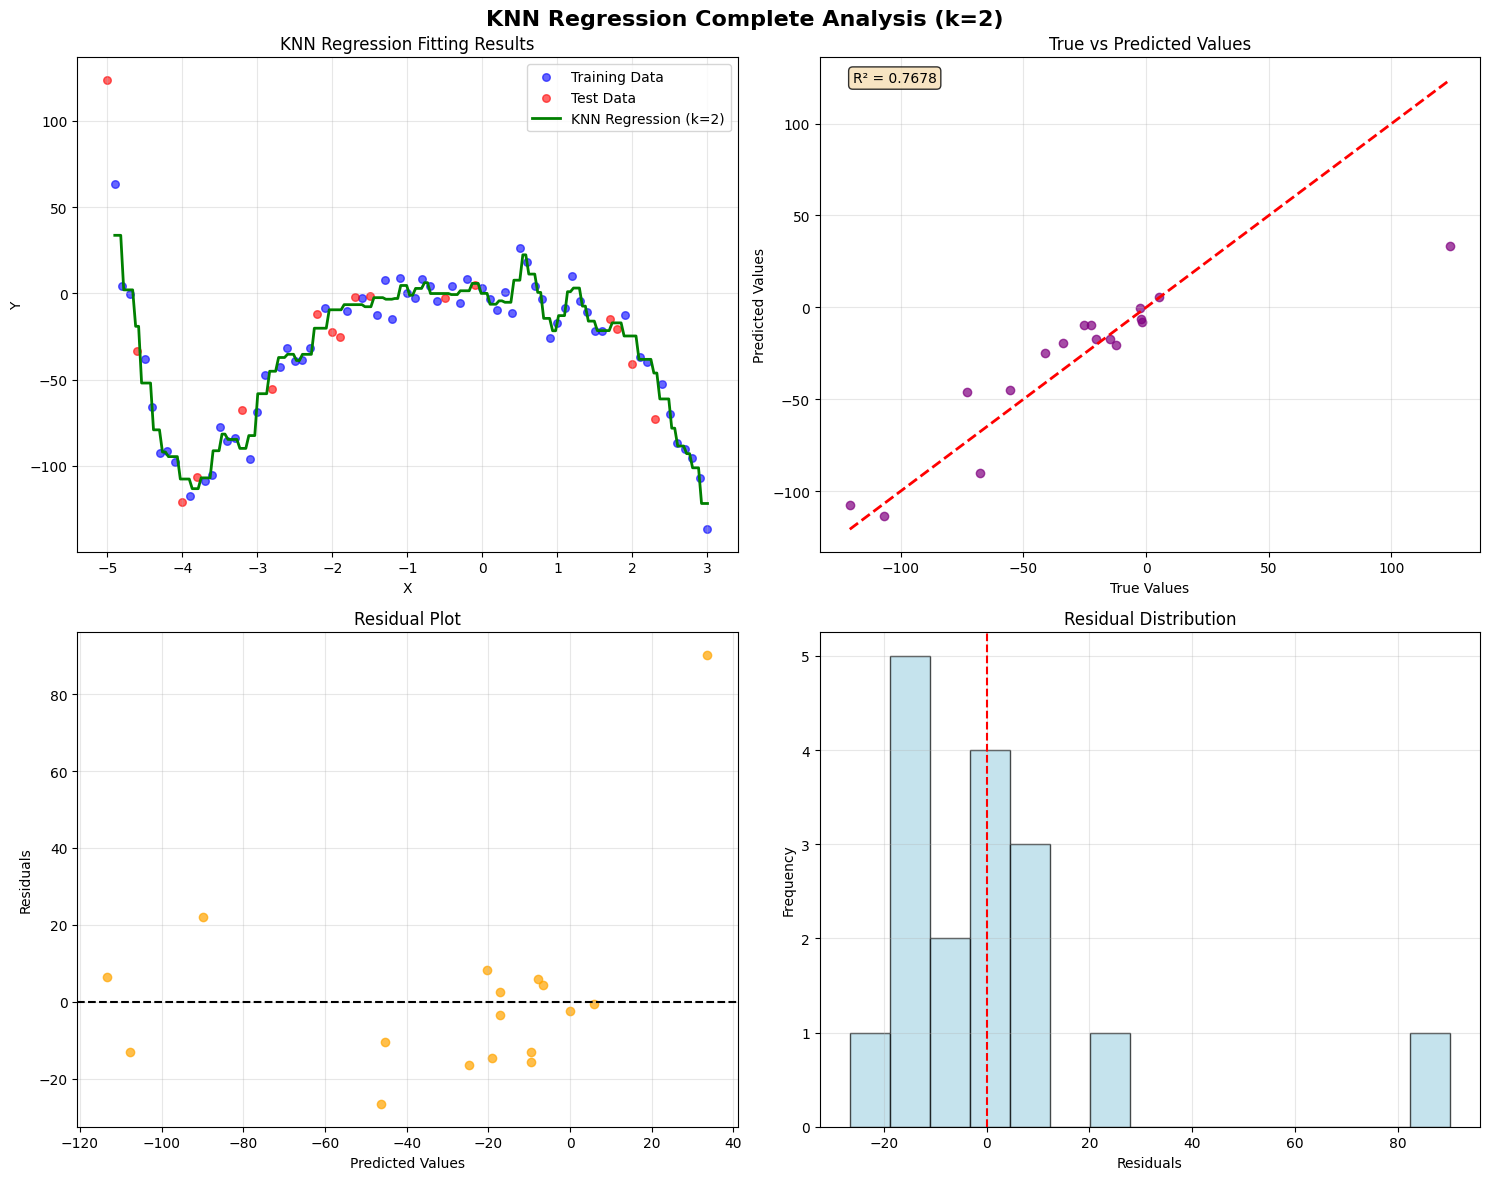

In [10]:
# 完整的回归结果可视化
def plot_regression_results(X_train, y_train, X_test, y_test, y_pred, model, title):
    """
    绘制回归结果的综合可视化
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # 1. 训练数据和回归曲线
    # 创建更密集的点用于绘制平滑曲线
    X_plot = np.linspace(X_train.min(), X_train.max(), 200).reshape(-1, 1)
    X_plot_scaled = scaler_X.transform(X_plot)
    y_plot_pred = model.predict(X_plot_scaled)

    axes[0, 0].scatter(
        X_train, y_train, alpha=0.6, color="blue", s=30, label="Training Data"
    )
    axes[0, 0].scatter(X_test, y_test, alpha=0.6, color="red", s=30, label="Test Data")
    axes[0, 0].plot(
        X_plot,
        y_plot_pred,
        color="green",
        linewidth=2,
        label=f"KNN Regression (k={model.n_neighbors})",
    )
    axes[0, 0].set_xlabel("X")
    axes[0, 0].set_ylabel("Y")
    axes[0, 0].set_title("KNN Regression Fitting Results")
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # 2. 真实值 vs 预测值
    axes[0, 1].scatter(y_test, y_pred, alpha=0.7, color="purple")
    axes[0, 1].plot(
        [y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--", lw=2
    )
    axes[0, 1].set_xlabel("True Values")
    axes[0, 1].set_ylabel("Predicted Values")
    axes[0, 1].set_title("True vs Predicted Values")
    axes[0, 1].grid(True, alpha=0.3)

    # 添加R²值
    r2 = r2_score(y_test, y_pred)
    axes[0, 1].text(
        0.05,
        0.95,
        f"R² = {r2:.4f}",
        transform=axes[0, 1].transAxes,
        bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.8),
    )

    # 3. 残差图
    residuals = y_test - y_pred
    axes[1, 0].scatter(y_pred, residuals, alpha=0.7, color="orange")
    axes[1, 0].axhline(y=0, color="black", linestyle="--")
    axes[1, 0].set_xlabel("Predicted Values")
    axes[1, 0].set_ylabel("Residuals")
    axes[1, 0].set_title("Residual Plot")
    axes[1, 0].grid(True, alpha=0.3)

    # 4. 残差分布
    axes[1, 1].hist(residuals, bins=15, alpha=0.7, color="lightblue", edgecolor="black")
    axes[1, 1].axvline(x=0, color="red", linestyle="--")
    axes[1, 1].set_xlabel("Residuals")
    axes[1, 1].set_ylabel("Frequency")
    axes[1, 1].set_title("Residual Distribution")
    axes[1, 1].grid(True, alpha=0.3)

    plt.suptitle(title, fontsize=16, fontweight="bold")
    plt.tight_layout()
    plt.show()


# 绘制最终模型的结果
plot_regression_results(
    X_train,
    y_train,
    X_test,
    y_test,
    y_pred_final,
    final_knn,
    f"KNN Regression Complete Analysis (k={best_k})",
)

比较不同距离度量的性能:
------------------------------------------------------------
euclidean    距离: RMSE=25.0861, MAE=15.0598, R²=0.7678
manhattan    距离: RMSE=25.0861, MAE=15.0598, R²=0.7678
chebyshev    距离: RMSE=25.0861, MAE=15.0598, R²=0.7678


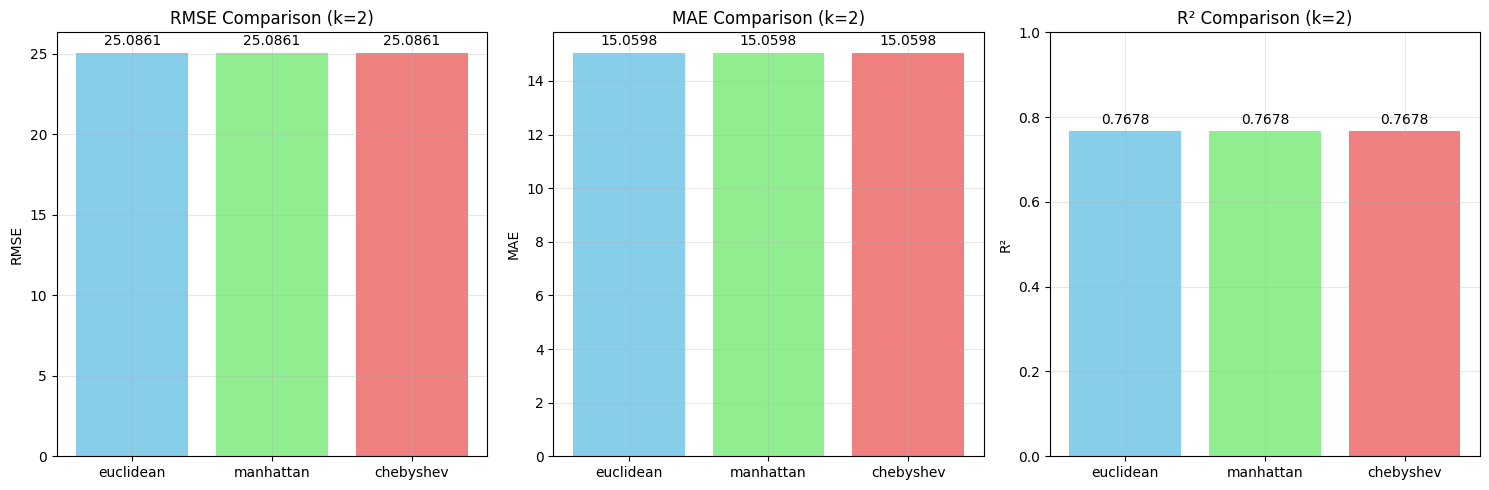


Best distance metric (RMSE): euclidean
Best distance metric (R²): euclidean


In [11]:
# 不同距离度量的比较（回归版本）
distance_metrics = ["euclidean", "manhattan", "chebyshev"]
distance_results = {}

print("比较不同距离度量的性能:")
print("-" * 60)

for metric in distance_metrics:
    knn_metric = KNeighborsRegressor(n_neighbors=best_k, metric=metric)
    knn_metric.fit(X_train_scaled, y_train_scaled)
    y_pred_metric = knn_metric.predict(X_test_scaled)

    mse_metric = mean_squared_error(y_test_scaled, y_pred_metric)
    rmse_metric = np.sqrt(mse_metric)
    mae_metric = mean_absolute_error(y_test_scaled, y_pred_metric)
    r2_metric = r2_score(y_test_scaled, y_pred_metric)

    distance_results[metric] = {"RMSE": rmse_metric, "MAE": mae_metric, "R2": r2_metric}

    print(
        f"{metric:12} 距离: RMSE={rmse_metric:.4f}, MAE={mae_metric:.4f}, R²={r2_metric:.4f}"
    )

# 可视化不同距离度量的比较
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = list(distance_results.keys())
colors = ["skyblue", "lightgreen", "lightcoral"]

# RMSE比较
rmse_scores = [distance_results[m]["RMSE"] for m in metrics]
bars1 = axes[0].bar(metrics, rmse_scores, color=colors)
axes[0].set_ylabel("RMSE")
axes[0].set_title(f"RMSE Comparison (k={best_k})")
axes[0].grid(True, alpha=0.3)
for bar, score in zip(bars1, rmse_scores):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01 * max(rmse_scores),
        f"{score:.4f}",
        ha="center",
        va="bottom",
    )

# MAE比较
mae_scores = [distance_results[m]["MAE"] for m in metrics]
bars2 = axes[1].bar(metrics, mae_scores, color=colors)
axes[1].set_ylabel("MAE")
axes[1].set_title(f"MAE Comparison (k={best_k})")
axes[1].grid(True, alpha=0.3)
for bar, score in zip(bars2, mae_scores):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01 * max(mae_scores),
        f"{score:.4f}",
        ha="center",
        va="bottom",
    )

# R²比较
r2_scores = [distance_results[m]["R2"] for m in metrics]
bars3 = axes[2].bar(metrics, r2_scores, color=colors)
axes[2].set_ylabel("R²")
axes[2].set_title(f"R² Comparison (k={best_k})")
axes[2].set_ylim(0, 1)
axes[2].grid(True, alpha=0.3)
for bar, score in zip(bars3, r2_scores):
    axes[2].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{score:.4f}",
        ha="center",
        va="bottom",
    )

plt.tight_layout()
plt.show()

# 找出最佳距离度量
best_metric_rmse = min(distance_results, key=lambda x: distance_results[x]["RMSE"])
best_metric_r2 = max(distance_results, key=lambda x: distance_results[x]["R2"])

print(f"\nBest distance metric (RMSE): {best_metric_rmse}")
print(f"Best distance metric (R²): {best_metric_r2}")

## KNN回归算法实现总结

### 完整流程回顾

#### 1. 数据探索和预处理
- **数据加载**: 使用pandas加载w3regr.csv回归数据集
- **数据分析**: 查看数据形状、分布、统计信息、相关性
- **数据可视化**: 绘制散点图、分布图、箱线图
- **特征工程**: 分离特征和标签，进行训练测试分割
- **数据标准化**: 使用StandardScaler进行特征标准化

#### 2. KNN回归算法实现
- **从零实现**: 编写完整的KNN回归器类
  - 距离计算：欧几里得距离
  - 邻居选择：按距离排序选择k个最近邻
  - 预测机制：计算k个邻居的平均值作为预测结果
- **scikit-learn实现**: 使用现成的KNeighborsRegressor进行对比

#### 3. 模型优化和评估
- **k值调优**: 使用交叉验证寻找最佳k值
- **距离度量比较**: 比较欧几里得、曼哈顿、切比雪夫距离
- **性能评估**: MSE、RMSE、MAE、R²等回归指标

#### 4. 结果可视化
- **回归曲线**: 可视化KNN回归的拟合效果
- **残差分析**: 真实值vs预测值、残差图、残差分布
- **性能比较**: 图表展示不同参数的影响

### KNN回归 vs KNN分类的关键差异

1. **预测方式**:
   - 分类：k个邻居进行多数投票
   - 回归：k个邻居的目标值求平均

2. **评估指标**:
   - 分类：准确率、精确率、召回率、F1分数
   - 回归：MSE、RMSE、MAE、R²

3. **可视化**:
   - 分类：决策边界、混淆矩阵
   - 回归：回归曲线、残差分析

### 关键发现

1. **数据预处理的重要性**: 特征标准化对KNN回归同样重要
2. **k值选择**: 需要平衡偏差和方差，避免过拟合和欠拟合
3. **距离度量**: 不同距离度量对连续值预测的影响
4. **残差分析**: 通过残差图检查模型的拟合质量

### KNN回归算法优缺点

#### 优点
- 简单直观，易于理解和实现
- 非参数方法，不假设数据分布
- 能够捕捉局部模式，适用于非线性关系
- 对异常值相对稳健（取决于k值）

#### 缺点
- 计算复杂度高，预测速度慢
- 对高维数据效果不佳（维度诅咒）
- 需要选择合适的k值和距离度量
- 对特征缩放敏感
- 在数据稀疏区域预测效果较差